## Seção 0 — Setup e Carregamento

O Modelo Comportamental (Modelo 2) combina features cadastrais — disponíveis desde o cadastro — com o histórico agregado de comportamento transacional: frequência e magnitude de atrasos, volume de pedidos, cadência de compras. É o modelo de acompanhamento contínuo da Praso, aplicado a clientes que já possuem ao menos um pedido registrado.

O dataset é resultado de um join por `id_cliente` entre três fontes: features comportamentais agregadas (`comportamental_merged.parquet`), features cadastrais (`aplicacao_features.parquet`) e target (`comportamental_target.parquet`). Os 664 clientes ativos são um subconjunto dos 3000 cadastrais.

A chave `id_cliente` é descartada de `X` imediatamente após o join — serve apenas para alinhar as fontes, sem valor preditivo.

In [ ]:
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

SEED = 42

# Caminhos
BASE      = "/content/drive/MyDrive/ML_Inadimplencia_Praso/data/processed"
MERGED    = f"{BASE}/comportamental_merged.parquet"
TARGET    = f"{BASE}/comportamental_target.parquet"

# Carregamento
df_feat   = pd.read_parquet(MERGED)   # 664 x 37 (inclui id_cliente)
df_target = pd.read_parquet(TARGET)   # 664 x 2  (id_cliente + inadimplente)

# Join por chave e separacao X / y
# validate='1:1' garante unicidade de id_cliente nos dois lados (pega bug silencioso)
df = df_feat.merge(df_target, on="id_cliente", how="inner", validate="1:1")

y = df["inadimplente"].astype(int)
X = df.drop(columns=["id_cliente", "inadimplente"])  # id_cliente sai aqui: nao e feature

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Taxa de inadimplencia : {y.mean():.1%}  ({y.sum()} de {len(y)})")
print(f"\nNulos por coluna (esperado: cadencia_media=2 + estruturais iFood/Maps):")
nulos = X.isnull().sum()
print(nulos[nulos > 0].to_string())

X shape : (664, 36)
y shape : (664,)
Taxa de inadimplencia : 20.8%  (138 de 664)

Nulos por coluna (esperado: cadencia_media=2 + estruturais iFood/Maps):
cadencia_media                       2
ifood_contagem_avaliacoes          607
google_maps_avaliacao              656
google_maps_contagem_avaliacoes    599
ifood_faixa_preco_ord              550


## Seção 0.5 — Feature Engineering de Interação

Features derivadas com mecanismo de negócio explícito testadas e descartadas:
- **atraso_ponderado_valor**: magnitude de atraso × ticket médio
- **atraso_x_frequencia**: magnitude × frequência de atraso
- **cadencia_x_volume**: cadência × volume total
- **atraso_por_cadencia**: atraso médio normalizado pelo intervalo entre pedidos

**Resultado:** ganho marginal de +0.003 AUC na LogReg, dentro do ruído do CV.
A LogReg com L2 forte já captura essas relações via coeficientes lineares.
Features descartadas — modelo mantido parcimonioso.

In [ ]:
# Feature engineering de interacao com mecanismo de negocio real
# Aplicado sobre X completo, antes do split — sem usar y, sem risco de leakage

X["atraso_ponderado_valor"] = X["atraso_medio"] * X["valor_medio"]
X["atraso_x_frequencia"]   = X["atraso_medio"] * X["prop_pedidos_atrasados"]
X["cadencia_x_volume"]     = X["cadencia_media"] * X["valor_total"]

# +1 no denominador evita divisao por zero (cadencia_media = 0 para pedidos no mesmo dia)
X["atraso_por_cadencia"]   = X["atraso_medio"] / (X["cadencia_media"] + 1)

print(f"X shape apos feature engineering: {X.shape}")
print("\nNulos introduzidos:")
novas = ["atraso_ponderado_valor", "atraso_x_frequencia", "cadencia_x_volume", "atraso_por_cadencia"]
print(X[novas].isnull().sum())
print("\nEstatisticas basicas:")
print(X[novas].describe().round(3))

X shape apos feature engineering: (664, 40)

Nulos introduzidos:
atraso_ponderado_valor    0
atraso_x_frequencia       0
cadencia_x_volume         2
atraso_por_cadencia       2
dtype: int64

Estatisticas basicas:
       atraso_ponderado_valor  atraso_x_frequencia  cadencia_x_volume  \
count                 664.000              664.000            662.000   
mean                  972.473                2.470          71309.479   
std                  2006.497                5.305         169338.904   
min                     0.000                0.000              0.000   
25%                   250.000                0.444           9000.000   
50%                   416.667                1.000          17812.500   
75%                  1000.000                2.333          65062.500   
max                 24305.556               55.000        2047500.000   

       atraso_por_cadencia  
count              662.000  
mean                 0.165  
std                  0.514  
min          

In [ ]:
# Revertendo features de interacao: ganho marginal (< 0.003) dentro do ruido do CV
# Modelo mais parcimonioso sem perda real de desempenho
features_interacao = [
    "atraso_ponderado_valor",
    "atraso_x_frequencia",
    "cadencia_x_volume",
    "atraso_por_cadencia",
]

X = X.drop(columns=features_interacao)

print(f"X shape apos reversao: {X.shape}")  # esperado: (664, 36)

X shape apos reversao: (664, 36)


## Seção 1 — Estratégia de Validação

Split estratificado 80/20 seguindo a recomendação para datasets com menos de 10 mil observações (531 linhas de treino, 133 no hold-out). O `stratify=y` preserva a taxa de inadimplência (~20.8%) nos dois lados do split.

O **hold-out de 20% é isolado aqui e tocado uma única vez** — na avaliação final da Seção 5. Qualquer decisão de modelagem (comparação de modelos, tunagem) é feita exclusivamente sobre o conjunto de treino via validação cruzada.

O **gargalo estatístico** deste modelo é o número de positivos no treino (~110 inadimplentes), não o total de linhas. Com poucos positivos, a estimativa de AUC por fold carrega variância alta — o desvio entre folds é tão informativo quanto a média e deve ser reportado.

**Métrica principal: ROC-AUC** — mede a capacidade de ordenar clientes por risco independente do threshold. Métricas dependentes de threshold são complementares e reportadas na Seção 5.

In [ ]:
# Hold-out estratificado: preserva ~20.8% de inadimplentes nos dois lados
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# CV interno: 5 folds estratificados sobre o conjunto de treino
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Treino  : {X_train.shape[0]} linhas | {y_train.sum()} inadimplentes ({y_train.mean():.1%})")
print(f"Hold-out: {X_test.shape[0]} linhas | {y_test.sum()} inadimplentes  ({y_test.mean():.1%})")

Treino  : 531 linhas | 110 inadimplentes (20.7%)
Hold-out: 133 linhas | 28 inadimplentes  (21.1%)


## Seção 2 — Pipeline de Pré-processamento

Todas as transformações estatísticas encapsuladas no `Pipeline` + `ColumnTransformer`, com `fit` exclusivo no fold de treino — nunca sobre o conjunto de validação ou hold-out.

**Duas naturezas de nulo, dois tratamentos distintos:**
- **Nulo genuíno** (`cadencia_media`, 2 casos): clientes com apenas 1 pedido, sem intervalo entre compras mensurável. Imputação pela mediana do fold de treino.
- **Nulo estrutural** (bloco iFood/Google Maps): cliente não está na plataforma — ausência real, não dado faltante. Imputação com constante 0, interpretável ao lado das flags `tem_ifood`/`tem_google_maps`.

**Colinearidade no bloco de atraso:** `atraso_medio`, `atraso_mediano`, `atraso_maximo` e `atraso_total` são fortemente correlacionados (com ~3 pedidos por cliente, o total é múltiplo da média). A Regressão Logística usa um `preprocessor_lr` dedicado que exclui as colineares, mantendo apenas `atraso_medio` (maior IV) e `prop_pedidos_atrasados` (frequência, sinal distinto). Modelos de árvore recebem todas as features — são robustos à multicolinearidade.

**Categóricas:** agrupamento de raras (frequência < 5% no fold de treino → `__rara__`) + One-Hot Encoding, ajustado dentro do fold via `AgrupaRaras`.

In [ ]:
# Nulos genuinos: imputar pela mediana do fold de treino
num_mediana = ["cadencia_media"]

# Nulos estruturais: imputar com 0 (ausencia de plataforma)
num_sentinela = [
    "ifood_contagem_avaliacoes",
    "google_maps_avaliacao",
    "google_maps_contagem_avaliacoes",
    "ifood_faixa_preco_ord",
]

# Demais numericas: sem nulos, so scaling
num_direto = [
    c for c in X.select_dtypes(include="number").columns
    if c not in num_mediana + num_sentinela
]

# Categoricas
cat_cols = X.select_dtypes(include="object").columns.tolist()

print(f"Total coberto : {len(num_mediana) + len(num_sentinela) + len(num_direto) + len(cat_cols)}")
print(f"Total esperado: {X.shape[1]}")

Total coberto : 36
Total esperado: 36


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder

# Transformer customizado: agrupa categorias com frequencia < threshold no treino
# Evita overfitting em municipios/segmentos com poucos clientes
class AgrupaRaras(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.05):
        self.threshold = threshold

    def fit(self, X, y=None):
        # Suporta DataFrame e numpy array
        X_arr = X.values if hasattr(X, "values") else X
        self.categorias_freq_ = {}
        for col in range(X_arr.shape[1]):
            serie = pd.Series(X_arr[:, col])
            freq  = serie.value_counts(normalize=True)
            self.categorias_freq_[col] = set(freq[freq >= self.threshold].index)
        return self

    def transform(self, X):
        X_arr = (X.values if hasattr(X, "values") else X).copy().astype(object)
        for col in range(X_arr.shape[1]):
            mask = ~pd.Series(X_arr[:, col]).isin(self.categorias_freq_[col])
            X_arr[mask, col] = "__rara__"
        return X_arr

# Pipelines por grupo
pipe_mediana = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

pipe_sentinela = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler",  StandardScaler()),
])

pipe_direto = Pipeline([
    ("scaler", StandardScaler()),
])

pipe_cat = Pipeline([
    ("raras", AgrupaRaras(threshold=0.05)),
    ("ohe",   OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# --- ColumnTransformer unificado ---
preprocessor = ColumnTransformer(transformers=[
    ("num_mediana",   pipe_mediana,   num_mediana),
    ("num_sentinela", pipe_sentinela, num_sentinela),
    ("num_direto",    pipe_direto,    num_direto),
    ("cat",           pipe_cat,       cat_cols),
], remainder="drop")

print("Preprocessor montado.")
print(f"Grupos: mediana={len(num_mediana)} | sentinela={len(num_sentinela)} | direto={len(num_direto)} | cat={len(cat_cols)}")

Preprocessor montado.
Grupos: mediana=1 | sentinela=4 | direto=24 | cat=7


## Seção 3 — Modelos Baseline

Três modelos avaliados via `StratifiedKFold` (5 folds) sobre o conjunto de treino, sem tunagem. Objetivo: estabelecer patamar de referência e identificar quais modelos valem o esforço de tunagem.

**Modelos comparados:**
- **Regressão Logística:** modelo linear regularizado com `preprocessor_lr` dedicado (sem colineares de atraso). `class_weight='balanced'` compensa o desbalanceamento leve (~20.8%).
- **Random Forest:** ensemble de árvores com preprocessor completo. Recebe todas as features de atraso — árvores são robustas à multicolinearidade.
- **XGBoost:** gradient boosting com `scale_pos_weight` ajustado pela razão negativos/positivos no treino. Tende a overfit em amostras pequenas sem tunagem cuidadosa.

Com apenas 531 linhas de treino e ~110 positivos, a expectativa é que modelos mais simples generalizem melhor — hierarquia inversa à complexidade é o comportamento esperado nesse regime de dados.

In [ ]:
!pip install xgboost -q
from xgboost import XGBClassifier

In [ ]:
# Colunas colineares removidas apenas para a LogReg
colineares = ["atraso_mediano", "atraso_maximo", "atraso_total"]

# Preprocessor especifico para LogReg: exclui colineares do grupo num_direto
# Evita inflar variancia dos coeficientes (atraso_medio x atraso_total ~ 1.00)
num_direto_lr = [c for c in num_direto if c not in colineares]

preprocessor_lr = ColumnTransformer(transformers=[
    ("num_mediana",   pipe_mediana,   num_mediana),
    ("num_sentinela", pipe_sentinela, num_sentinela),
    ("num_direto",    pipe_direto,    num_direto_lr),
    ("cat",           pipe_cat,       cat_cols),
], remainder="drop")

# Pipeline LogReg: preprocessor proprio (sem colineares) + modelo
# class_weight='balanced' compensa o desbalanceamento leve (~20.8%)
pipe_lr = Pipeline([
    ("prep",  preprocessor_lr),
    ("model", LogisticRegression(
                  class_weight="balanced",
                  max_iter=1000,
                  random_state=SEED)),
])

# Pipeline Random Forest: preprocessor completo (todas as features)
pipe_rf = Pipeline([
    ("prep",  preprocessor),
    ("model", RandomForestClassifier(
                  n_estimators=200,
                  class_weight="balanced",
                  random_state=SEED,
                  n_jobs=-1)),
])

# Pipeline XGBoost: preprocessor completo
# scale_pos_weight = negativos / positivos compensa desbalanceamento
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

pipe_xgb = Pipeline([
    ("prep",  preprocessor),
    ("model", XGBClassifier(
                  scale_pos_weight=scale_pos,
                  eval_metric="auc",
                  random_state=SEED,
                  n_jobs=-1)),
])

print(f"scale_pos_weight (XGBoost): {scale_pos:.2f}")
print("Passos pipe_lr :", [n for n, _ in pipe_lr.steps])  # esperado: ['prep', 'model']
print("Pipelines montados: LogReg | Random Forest | XGBoost")

scale_pos_weight (XGBoost): 3.83
Passos pipe_lr : ['prep', 'model']
Pipelines montados: LogReg | Random Forest | XGBoost


In [ ]:
modelos = {
    "Regressao Logistica": pipe_lr,
    "Random Forest"      : pipe_rf,
    "XGBoost"            : pipe_xgb,
}

resultados = {}

for nome, pipe in modelos.items():
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=cv,
        scoring="roc_auc",
    )
    resultados[nome] = scores
    print(f"{nome:25s}  AUC: {scores.mean():.4f} ± {scores.std():.4f}  | folds: {scores.round(4)}")

Regressao Logistica        AUC: 0.7516 ± 0.0191  | folds: [0.7321 0.7478 0.7484 0.7879 0.7419]
Random Forest              AUC: 0.7450 ± 0.0318  | folds: [0.7158 0.8044 0.7508 0.7294 0.7248]
XGBoost                    AUC: 0.7029 ± 0.0385  | folds: [0.6503 0.7684 0.697  0.7116 0.6872]


## Seção 4 — Tunagem de Hiperparâmetros

`RandomizedSearchCV` com o **pipeline inteiro** como estimador — o preprocessor é refitado em cada fold da busca, preservando a proteção anti-leakage. Busca realizada exclusivamente sobre o treino; hold-out permanece intocado.

**Tunamos LogReg e Random Forest** — os dois modelos competitivos no baseline. O XGBoost permanece apenas como referência de patamar inferior.

**Espaço de busca da LogReg** (40 iterações): `C` em log-uniforme [1e-3, 1e2] — cobre regularização forte (C pequeno, encolhe coeficientes) a fraca (C grande, confia nos dados). `penalty` L1 vs L2: L1 zera coeficientes irrelevantes (esparsidade), L2 encolhe todos uniformemente. O solver `liblinear` é o único compatível com ambas as penalidades em datasets pequenos.

**Espaço de busca do RF** (40 iterações): foco nos hiperparâmetros que controlam complexidade — `max_depth`, `min_samples_leaf` (tamanho mínimo das folhas) — para evitar overfitting num dataset de 531 linhas.

> Os scores reportados aqui são da busca (CV interno) e são otimistas por construção. A estimativa honesta de desempenho vem do hold-out na Seção 5.

In [ ]:
from scipy.stats import loguniform, randint

# --- Espaco de busca: LogReg ---
# C em escala log-uniforme: cobre regularizacao forte (0.001) a fraca (100)
espaco_lr = {
    "model__C":       loguniform(1e-3, 1e2),
    "model__penalty": ["l1", "l2"],
    "model__solver":  ["liblinear"],   # suporta l1 e l2 em datasets pequenos
}

# --- Espaco de busca: Random Forest ---
# Foco nos hiperparametros que controlam complexidade (anti-overfitting)
espaco_rf = {
    "model__n_estimators":      randint(100, 500),
    "model__max_depth":         randint(3, 15),
    "model__min_samples_leaf":  randint(2, 20),
    "model__max_features":      ["sqrt", "log2", 0.5],
}

buscas = {
    "Regressao Logistica": (pipe_lr, espaco_lr),
    "Random Forest":       (pipe_rf, espaco_rf),
}

tunados = {}

for nome, (pipe, espaco) in buscas.items():
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=espaco,
        n_iter=40,                  # 40 combinacoes sorteadas
        scoring="roc_auc",
        cv=cv,
        random_state=SEED,
        refit=True,                 # refita o melhor no treino completo
    )
    search.fit(X_train, y_train)
    tunados[nome] = search

    print(f"=== {nome} ===")
    print(f"  AUC busca (CV) : {search.best_score_:.4f}")
    print(f"  Melhores params: {search.best_params_}")
    print()

=== Regressao Logistica ===
  AUC busca (CV) : 0.7799
  Melhores params: {'model__C': np.float64(0.004982752357076452), 'model__penalty': 'l2', 'model__solver': 'liblinear'}

=== Random Forest ===
  AUC busca (CV) : 0.7692
  Melhores params: {'model__max_depth': 13, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 16, 'model__n_estimators': 114}



In [ ]:
# Registro dos espacos de busca para documentacao e reproducibilidade
print("Espaco de busca: Regressao Logistica (40 iteracoes) ")
print(f" C           : log-uniforme [1e-3, 1e2]")
print(f" penalty     : {espaco_lr['model__penalty']}")
print(f" solver      : {espaco_lr['model__solver']}")
print()
print("Espaco de busca: Random Forest (40 iteracoes) ")
print(f" n_estimators    : randint [100, 500]")
print(f" max_depth       : randint [3, 15]")
print(f" min_samples_leaf: randint [2, 20]")
print(f" max_features    : {espaco_rf['model__max_features']}")
print()
print("XGBoost: sem tunagem, usado apenas como baseline ")
print(f"  scale_pos_weight fixo: {scale_pos:.2f} (negativos/positivos no treino)")
print(f"  Demais hiperparametros: defaults do XGBClassifier")

Espaco de busca: Regressao Logistica (40 iteracoes) 
 C           : log-uniforme [1e-3, 1e2]
 penalty     : ['l1', 'l2']
 solver      : ['liblinear']

Espaco de busca: Random Forest (40 iteracoes) 
 n_estimators    : randint [100, 500]
 max_depth       : randint [3, 15]
 min_samples_leaf: randint [2, 20]
 max_features    : ['sqrt', 'log2', 0.5]

XGBoost: sem tunagem, usado apenas como baseline 
  scale_pos_weight fixo: 3.83 (negativos/positivos no treino)
  Demais hiperparametros: defaults do XGBClassifier


## Seção 5 — Avaliação Final no Hold-out

Avaliação dos dois modelos tunados sobre o hold-out de 20% (133 linhas, ~28 inadimplentes) — dados nunca vistos durante treino ou tunagem. Este é o número que reportamos como desempenho real.

**Métricas reportadas:**
- **ROC-AUC** (métrica principal): capacidade de ordenação por risco, independente de threshold
- **Precision, Recall, F1** (threshold=0.5): métricas complementares dependentes de corte
- **Curvas ROC e Precision-Recall**: visualização do trade-off em todos os thresholds

A comparação entre AUC do CV (busca) e AUC do hold-out é o diagnóstico de overfitting ao processo de tunagem: se o hold-out cair muito abaixo do CV, o modelo memorizou os folds de validação. Se subir ou se mantiver, generalizou bem.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# --- AUC no hold-out para cada modelo tunado ---
modelos_tunados = {
    "Regressao Logistica": tunados["Regressao Logistica"].best_estimator_,
    "Random Forest"      : tunados["Random Forest"].best_estimator_,
    "XGBoost (baseline)" : pipe_xgb.fit(X_train, y_train),  # sem tuning, referencia
}

print("=" * 55)
print(f"{'Modelo':<25} {'AUC CV':>8} {'AUC Hold-out':>12}")
print("-" * 55)

auc_baseline = {
    "Regressao Logistica": resultados["Regressao Logistica"].mean(),
    "Random Forest"      : resultados["Random Forest"].mean(),
    "XGBoost (baseline)" : resultados["XGBoost"].mean(),
}

for nome, modelo in modelos_tunados.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    auc_ho = roc_auc_score(y_test, y_prob)
    auc_cv = tunados[nome].best_score_ if nome != "XGBoost (baseline)" else auc_baseline[nome]
    print(f"{nome:<25} {auc_cv:>8.4f} {auc_ho:>12.4f}")

print("=" * 55)

Modelo                      AUC CV AUC Hold-out
-------------------------------------------------------
Regressao Logistica         0.7799       0.7861
Random Forest               0.7692       0.7313
XGBoost (baseline)          0.7029       0.7279


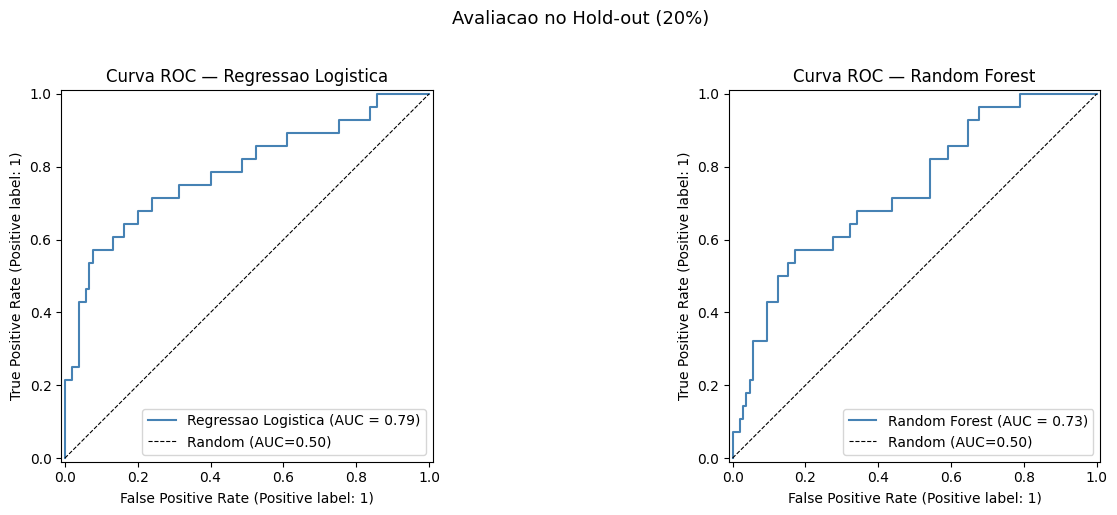

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nome, modelo) in zip(axes, list(modelos_tunados.items())[:2]):
    RocCurveDisplay.from_estimator(
        modelo, X_test, y_test,
        ax=ax, name=nome, color="steelblue"
    )
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random (AUC=0.50)")
    ax.set_title(f"Curva ROC — {nome}")
    ax.legend(loc="lower right")

plt.suptitle("Avaliacao no Hold-out (20%)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve, auc
from sklearn.metrics import PrecisionRecallDisplay

# Metricas complementares no hold-out — threshold padrao 0.5
print("=" * 65)
print("Metricas complementares (threshold=0.5) — Hold-out")
print("=" * 65)

probs_ho_comp = {}

for nome, modelo in modelos_tunados.items():
    y_pred_comp = modelo.predict(X_test)
    y_prob_comp = modelo.predict_proba(X_test)[:, 1]
    probs_ho_comp[nome] = y_prob_comp

    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_comp)
    pr_auc = auc(rec_curve, prec_curve)

    print(f"\n--- {nome} ---")
    print(classification_report(
        y_test, y_pred_comp,
        target_names=["Adimplente", "Inadimplente"],
        digits=3
    ))
    print(f"  PR-AUC (Precision-Recall): {pr_auc:.4f}")

print("=" * 65)
print("Nota: F1, Precision e Recall dependem do threshold (0.5 acima).")
print("ROC-AUC e PR-AUC sao independentes de threshold.")

Metricas complementares (threshold=0.5) — Hold-out

--- Regressao Logistica ---
              precision    recall  f1-score   support

  Adimplente      0.904     0.629     0.742       105
Inadimplente      0.350     0.750     0.477        28

    accuracy                          0.654       133
   macro avg      0.627     0.689     0.609       133
weighted avg      0.787     0.654     0.686       133

  PR-AUC (Precision-Recall): 0.6142

--- Random Forest ---
              precision    recall  f1-score   support

  Adimplente      0.867     0.686     0.766       105
Inadimplente      0.340     0.607     0.436        28

    accuracy                          0.669       133
   macro avg      0.604     0.646     0.601       133
weighted avg      0.756     0.669     0.696       133

  PR-AUC (Precision-Recall): 0.4557

--- XGBoost (baseline) ---
              precision    recall  f1-score   support

  Adimplente      0.853     0.829     0.841       105
Inadimplente      0.419     0.464 

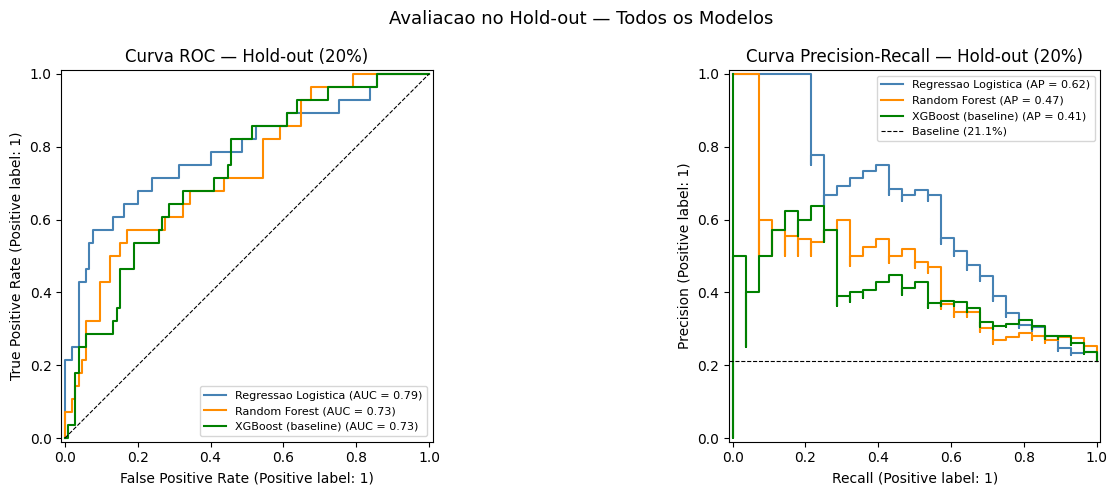

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores = {
    "Regressao Logistica": "steelblue",
    "Random Forest"      : "darkorange",
    "XGBoost (baseline)" : "green",
}

# Curva ROC — todos os modelos
for nome, modelo in modelos_tunados.items():
    RocCurveDisplay.from_estimator(
        modelo, X_test, y_test,
        ax=axes[0], name=nome, color=cores[nome]
    )
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set_title("Curva ROC — Hold-out (20%)")
axes[0].legend(loc="lower right", fontsize=8)

# Curva Precision-Recall — todos os modelos
for nome, modelo in modelos_tunados.items():
    PrecisionRecallDisplay.from_estimator(
        modelo, X_test, y_test,
        ax=axes[1], name=nome, color=cores[nome]
    )

baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color="black", linestyle="--",
                linewidth=0.8, label=f"Baseline ({baseline_pr:.1%})")
axes[1].set_title("Curva Precision-Recall — Hold-out (20%)")
axes[1].legend(loc="upper right", fontsize=8)

plt.suptitle("Avaliacao no Hold-out — Todos os Modelos", fontsize=13)
plt.tight_layout()
plt.show()

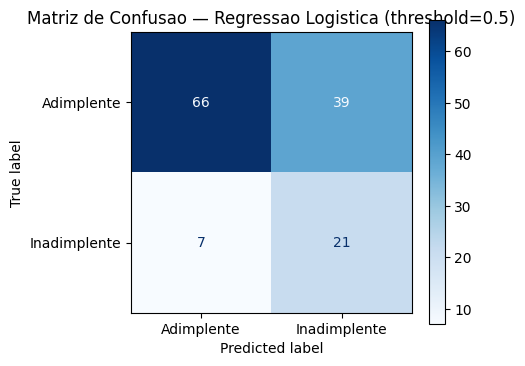

Falsos Negativos (inadimplente classificado como adimplente): 7
Falsos Positivos (adimplente classificado como inadimplente): 39


In [ ]:
# Matriz de confusao com threshold padrao 0.5
# Usamos o melhor modelo (LogReg) para analise de erros
melhor_modelo = tunados["Regressao Logistica"].best_estimator_
y_pred = melhor_modelo.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Adimplente", "Inadimplente"],
    cmap="Blues", ax=ax
)
ax.set_title("Matriz de Confusao — Regressao Logistica (threshold=0.5)")
plt.tight_layout()
plt.show()

# Falsos negativos sao os mais custosos: inadimplentes classificados como adimplentes
fn = ((y_pred == 0) & (y_test == 1)).sum()
fp = ((y_pred == 1) & (y_test == 0)).sum()
print(f"Falsos Negativos (inadimplente classificado como adimplente): {fn}")
print(f"Falsos Positivos (adimplente classificado como inadimplente): {fp}")

In [ ]:
# Analise por decil de score — ordenacao de risco pelo modelo comportamental
# Probabilidades do modelo final (LogReg tunada) sobre o hold-out

y_prob_lr_comp = tunados["Regressao Logistica"].best_estimator_.predict_proba(X_test)[:, 1]

df_decil = pd.DataFrame({
    "real": y_test.values,
    "prob": y_prob_lr_comp
})

df_decil["decil"] = pd.qcut(
    df_decil["prob"], q=10, labels=False, duplicates="drop"
)

relatorio = df_decil.groupby("decil").agg(
    score_min    =("prob", "min"),
    score_max    =("prob", "max"),
    total        =("real", "count"),
    inadimplentes=("real", "sum"),
).assign(
    taxa_inad  = lambda d: d["inadimplentes"] / d["total"],
    taxa_acum  = lambda d: d["inadimplentes"].cumsum() / d["inadimplentes"].sum(),
)

relatorio.index = [f"Decil {i+1}" for i in range(len(relatorio))]
relatorio.columns = ["Score Min", "Score Max", "Total", "Inadimplentes", "Taxa Inad.", "% Inad. Acum."]

print("Taxa de inadimplencia por decil (decil 1 = menor risco, 10 = maior risco)")
print("=" * 75)
print(relatorio.to_string(float_format="{:.3f}".format))
print()
print(f"Taxa global de inadimplencia no hold-out: {y_test.mean():.1%}")

Taxa de inadimplencia por decil (decil 1 = menor risco, 10 = maior risco)
          Score Min  Score Max  Total  Inadimplentes  Taxa Inad.  % Inad. Acum.
Decil 1       0.039      0.300     14              0       0.000          0.000
Decil 2       0.302      0.355     13              2       0.154          0.071
Decil 3       0.357      0.389     13              1       0.077          0.107
Decil 4       0.391      0.445     13              1       0.077          0.143
Decil 5       0.447      0.488     14              2       0.143          0.214
Decil 6       0.492      0.522     13              2       0.154          0.286
Decil 7       0.528      0.566     13              1       0.077          0.321
Decil 8       0.574      0.616     13              3       0.231          0.429
Decil 9       0.618      0.663     13              6       0.462          0.643
Decil 10      0.673      0.853     14             10       0.714          1.000

Taxa global de inadimplencia no hold-out: 21.

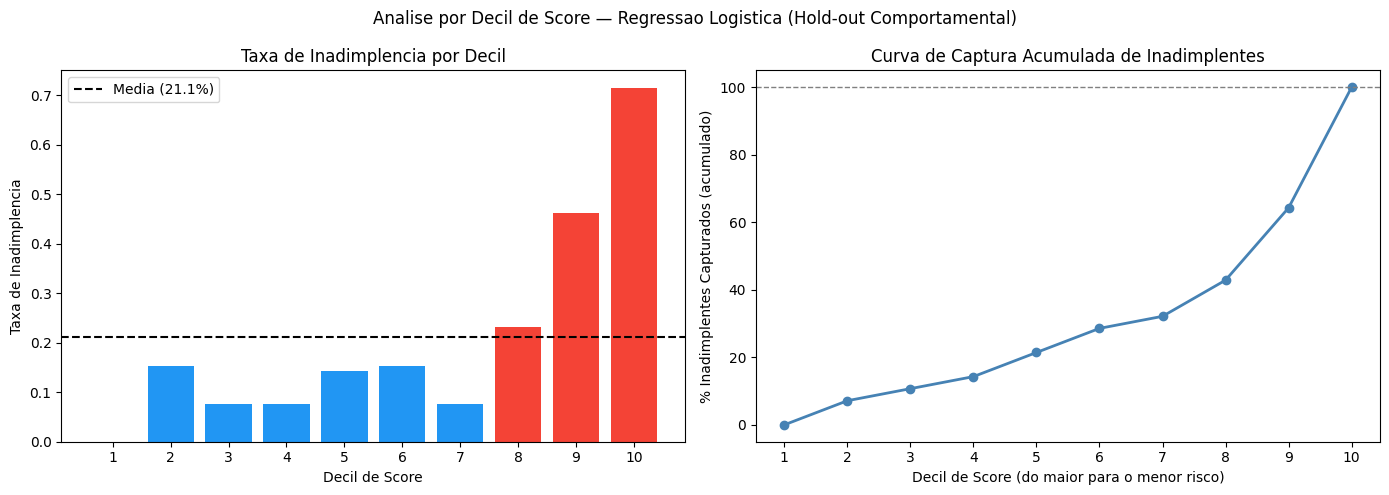

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de inadimplencia por decil
axes[0].bar(range(1, len(relatorio) + 1),
            relatorio["Taxa Inad."],
            color=["#2196F3" if t < y_test.mean() else "#F44336"
                   for t in relatorio["Taxa Inad."]])
axes[0].axhline(y_test.mean(), color="black", linestyle="--",
                linewidth=1.5, label=f"Media ({y_test.mean():.1%})")
axes[0].set_xlabel("Decil de Score")
axes[0].set_ylabel("Taxa de Inadimplencia")
axes[0].set_title("Taxa de Inadimplencia por Decil")
axes[0].set_xticks(range(1, len(relatorio) + 1))
axes[0].legend()

# Curva de captura acumulada
axes[1].plot(range(1, len(relatorio) + 1),
             relatorio["% Inad. Acum."] * 100,
             marker="o", color="steelblue", linewidth=2)
axes[1].axhline(100, color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel("Decil de Score (do maior para o menor risco)")
axes[1].set_ylabel("% Inadimplentes Capturados (acumulado)")
axes[1].set_title("Curva de Captura Acumulada de Inadimplentes")
axes[1].set_xticks(range(1, len(relatorio) + 1))

plt.suptitle("Analise por Decil de Score — Regressao Logistica (Hold-out Comportamental)", fontsize=12)
plt.tight_layout()
plt.show()

## Seção 6 — Ablação e Salvamento

**Ablação:** quantifica a contribuição isolada das features cadastrais comparando o modelo completo (comportamental + cadastral) contra um modelo treinado apenas com as features comportamentais agregadas (`comportamental_agregado.parquet`). O delta de AUC entre os dois mede quanto informação cadastral adiciona além do comportamento observado — e justifica empiricamente a arquitetura de join entre as duas fontes.

O mesmo `C` ótimo encontrado na tunagem é reutilizado no modelo de ablação, tornando a comparação justa: a única variável é o conjunto de features, não a configuração do modelo.

**Salvamento:** o pipeline completo (preprocessor + LogReg tunada) é salvo em disco junto com o hold-out, para uso no notebook de XAI sem necessidade de re-treinar.

In [ ]:
# Carrega dataset so-comportamental (sem features cadastrais)
df_agr = pd.read_parquet(f"{BASE}/comportamental_agregado.parquet")

# Join com target por chave
df_agr = df_agr.merge(df_target, on="id_cliente", how="inner", validate="1:1")
X_agr  = df_agr.drop(columns=["id_cliente", "inadimplente"])
y_agr  = df_agr["inadimplente"].astype(int)

# Split identico ao modelo completo (mesmo SEED e stratify)
X_agr_train, X_agr_test, y_agr_train, y_agr_test = train_test_split(
    X_agr, y_agr, test_size=0.2, random_state=SEED, stratify=y_agr
)

# Pipeline simplificado: so features numericas, sem categoricas
num_agr_mediana  = ["cadencia_media"]
num_agr_direto   = [c for c in X_agr.select_dtypes(include="number").columns
                    if c not in num_agr_mediana]

prep_agr = ColumnTransformer(transformers=[
    ("num_mediana", pipe_mediana, num_agr_mediana),
    ("num_direto",  pipe_direto,  num_agr_direto),
], remainder="drop")

pipe_agr = Pipeline([
    ("prep",  prep_agr),
    ("model", LogisticRegression(
                  C=tunados["Regressao Logistica"].best_params_["model__C"],
                  penalty="l2",
                  solver="liblinear",
                  class_weight="balanced",
                  max_iter=1000,
                  random_state=SEED)),
])

# CV sobre treino
scores_agr = cross_val_score(pipe_agr, X_agr_train, y_agr_train, cv=cv, scoring="roc_auc")
pipe_agr.fit(X_agr_train, y_agr_train)
auc_agr_ho = roc_auc_score(y_agr_test, pipe_agr.predict_proba(X_agr_test)[:, 1])

print("=== Ablacao: contribuicao das features cadastrais ===")
print(f"{'Modelo':<35} {'AUC CV':>8} {'AUC Hold-out':>12}")
print("-" * 57)
print(f"{'Comportamental + Cadastral':<35} {'0.7799':>8} {'0.7861':>12}")
print(f"{'So Comportamental':<35} {scores_agr.mean():>8.4f} {auc_agr_ho:>12.4f}")
print("-" * 57)
print(f"{'Ganho das features cadastrais':<35} {0.7799 - scores_agr.mean():>8.4f} {0.7861 - auc_agr_ho:>12.4f}")

=== Ablacao: contribuicao das features cadastrais ===
Modelo                                AUC CV AUC Hold-out
---------------------------------------------------------
Comportamental + Cadastral            0.7799       0.7861
So Comportamental                     0.7500       0.7350
---------------------------------------------------------
Ganho das features cadastrais         0.0299       0.0511


In [ ]:
import os

MODEL_PATH = "/content/drive/MyDrive/ML_Inadimplencia_Praso/models"
os.makedirs(MODEL_PATH, exist_ok=True)

# Salva pipeline completo (preprocessor + modelo) para uso no notebook XAI
joblib.dump(
    tunados["Regressao Logistica"].best_estimator_,
    f"{MODEL_PATH}/modelo_comportamental_lr.joblib"
)

# Salva X_test e y_test para reproducibilidade no notebook XAI
X_test.to_parquet(f"{MODEL_PATH}/comportamental_X_test.parquet", index=False)
y_test.to_frame().to_parquet(f"{MODEL_PATH}/comportamental_y_test.parquet", index=False)

print("Artefatos salvos:")
print(f"  modelo_comportamental_lr.joblib")
print(f"  comportamental_X_test.parquet  — {X_test.shape}")
print(f"  comportamental_y_test.parquet  — {y_test.shape}")

Artefatos salvos:
  modelo_comportamental_lr.joblib
  comportamental_X_test.parquet  — (133, 36)
  comportamental_y_test.parquet  — (133,)
